# Lab 2 - Phân khúc khách hàng bằng Clustering

**Mục tiêu:** phân nhóm khách hàng theo tuổi, thu nhập hằng năm và điểm chi tiêu; đánh giá kết quả bằng Silhouette, Davies-Bouldin và Calinski-Harabasz theo Chapter 3.

> **Lưu ý quan trọng:** đề bài là **clustering (học không giám sát)**, không phải classification. Phần classification ở cuối notebook là phần mở rộng: mô hình học nhãn cụm do K-Means tạo ra (pseudo-label), không phải nhãn thật.

**Dữ liệu:** do đề không cung cấp tệp CSV, notebook dùng bộ dữ liệu khách hàng mô phỏng 200 dòng, được sinh với `random seed = 42` để có thể tái lập. Khi có dữ liệu thật, chỉ cần thay `data/input/mall_customers.csv` và giữ nguyên tên cột.

## Step 1 - Import thư viện và cấu hình

Notebook tự tìm thư mục gốc dự án nên có thể chạy bằng Jupyter Notebook, JupyterLab hoặc VS Code.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, classification_report,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
candidates = [Path.cwd(), Path.cwd().parent]
ROOT = next(p for p in candidates if (p / 'data/input/mall_customers.csv').exists())
INPUT = ROOT / 'data/input'
OUTPUT = ROOT / 'data/output'
OUTPUT.mkdir(parents=True, exist_ok=True)
print('Project root:', ROOT)

mkdir -p failed for path C:\Users\Administrator\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\Administrator\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\Administrator\AppData\Local\Temp\matplotlib-v3xunanz because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Project root: C:\Users\Administrator\Desktop\Lab 2


## Step 2 - Đọc và khám phá dữ liệu (EDA)

Kiểm tra kích thước, kiểu dữ liệu, giá trị thiếu, dòng trùng, thống kê mô tả và ngoại lệ theo quy tắc IQR. `CustomerID` chỉ là mã định danh nên không được dùng làm đặc trưng phân cụm.

In [2]:
df = pd.read_csv(INPUT / 'mall_customers.csv')
display(df.head())
print('Shape:', df.shape)
print('Missing values:\n', df.isna().sum())
print('Duplicated rows:', df.duplicated().sum())
display(df.describe(include='all').T)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,28,41,43
1,2,Female,23,24,36
2,3,Female,34,28,42
3,4,Female,39,35,45
4,5,Female,29,37,26


Shape: (200, 5)
Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Duplicated rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,200.0,NaN,NaN,NaN,100.5,57.879185,1.0,50.75,100.5,150.25,200.0
Gender,200,2,Female,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,200.0,NaN,NaN,NaN,37.785,11.263798,18.0,29.0,36.0,43.25,70.0
Annual Income (k$),200.0,NaN,NaN,NaN,52.68,21.293536,15.0,32.0,51.0,73.0,97.0
Spending Score (1-100),200.0,NaN,NaN,NaN,50.535,23.888745,1.0,31.0,47.0,72.25,100.0


Outliers by IQR rule:
 Age                       4
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


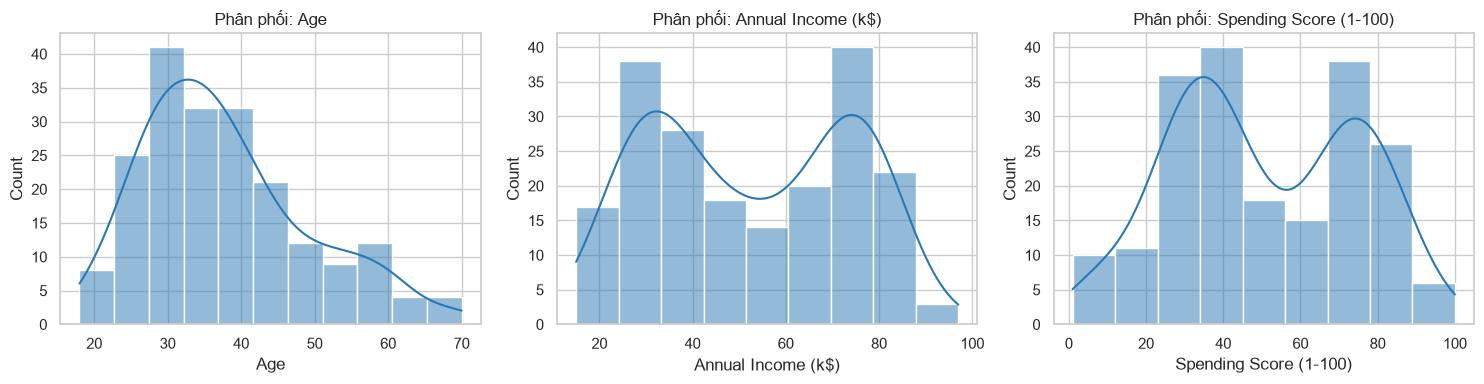

In [3]:
numeric = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
q1, q3 = df[numeric].quantile(.25), df[numeric].quantile(.75)
iqr = q3 - q1
outlier_count = ((df[numeric] < q1 - 1.5*iqr) | (df[numeric] > q3 + 1.5*iqr)).sum()
print('Outliers by IQR rule:\n', outlier_count)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for col, ax in zip(numeric, axes):
    sns.histplot(df[col], kde=True, ax=ax, color='#2878B5')
    ax.set_title(f'Phân phối: {col}')
fig.tight_layout()
fig.savefig(OUTPUT / '01_feature_distributions.png', dpi=160, bbox_inches='tight')
plt.show()

## Step 3 - Tiền xử lý và chuẩn hóa

Sử dụng `StandardScaler` để đưa `Age`, `Annual Income (k$)` và `Spending Score (1-100)` về cùng thang đo. Biến `Gender` được giữ để mô tả cụm nhưng không đưa vào K-Means chính, đúng theo yêu cầu chuẩn hóa ba biến số trong đề.

In [4]:
X = df[numeric].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Mean after scaling:', np.round(X_scaled.mean(axis=0), 4))
print('Std after scaling:', np.round(X_scaled.std(axis=0), 4))

Mean after scaling: [0. 0. 0.]
Std after scaling: [1. 1. 1.]


## Step 4 - Thử nghiệm K-Means với k = 2..10

Chọn số cụm dựa trên nhiều tiêu chí: Silhouette cao, Davies-Bouldin thấp, Calinski-Harabasz cao. Inertia được dùng cho phương pháp Elbow.

  File "C:\Users\Administrator\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,382.1832,0.3402,1.2344,112.8457
1,3,239.0674,0.4313,0.8778,148.7106
2,4,163.7461,0.4735,0.7325,174.0617
3,5,107.3492,0.5067,0.7107,223.7252
4,6,96.9706,0.4619,0.7581,201.2728
5,7,88.4756,0.4105,0.9142,185.9725
6,8,81.2063,0.3824,1.0304,175.2300
7,9,74.4998,0.3322,1.1270,168.4073
8,10,70.1269,0.3128,1.1478,159.5138


Số cụm tốt nhất theo Silhouette: 5


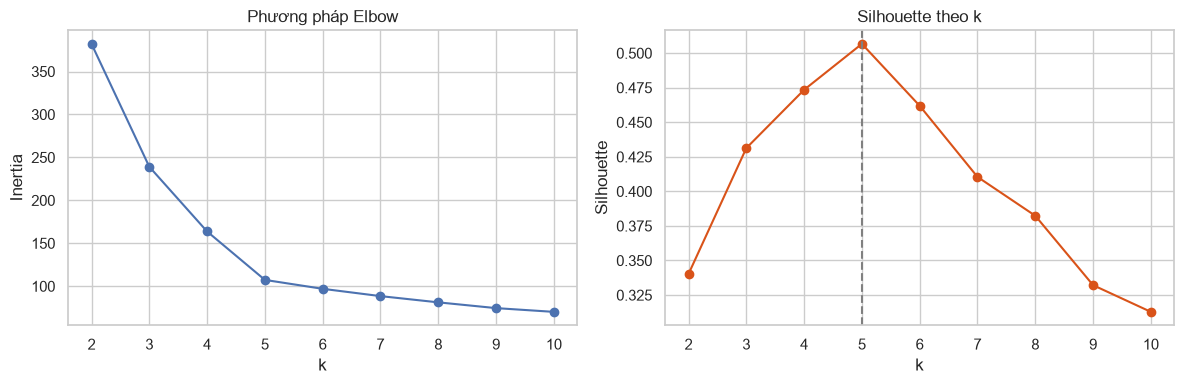

In [5]:
rows = []
models = {}
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    models[k] = model
    rows.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(X_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(X_scaled, labels),
    })
metrics = pd.DataFrame(rows)
display(metrics.round(4))
metrics.to_csv(OUTPUT / 'kmeans_metrics.csv', index=False)
best_k = int(metrics.loc[metrics['silhouette'].idxmax(), 'k'])
print('Số cụm tốt nhất theo Silhouette:', best_k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(metrics.k, metrics.inertia, marker='o')
axes[0].set(title='Phương pháp Elbow', xlabel='k', ylabel='Inertia')
axes[1].plot(metrics.k, metrics.silhouette, marker='o', color='#D95319')
axes[1].axvline(best_k, ls='--', color='gray')
axes[1].set(title='Silhouette theo k', xlabel='k', ylabel='Silhouette')
fig.tight_layout()
fig.savefig(OUTPUT / '02_k_selection.png', dpi=160, bbox_inches='tight')
plt.show()

## Step 5 - So sánh các thuật toán

So sánh K-Means, Agglomerative Clustering (Ward) và DBSCAN. Với DBSCAN, nhãn `-1` là nhiễu; các chỉ số nội bộ chỉ được tính trên những điểm không phải nhiễu khi tồn tại ít nhất hai cụm hợp lệ.

In [6]:
algorithms = {
    f'KMeans(k={best_k})': KMeans(n_clusters=best_k, random_state=42, n_init=20),
    f'Agglomerative(k={best_k})': AgglomerativeClustering(n_clusters=best_k, linkage='ward'),
    'DBSCAN(eps=0.55,min_samples=6)': DBSCAN(eps=.55, min_samples=6),
}
comparison = []
labels_by_model = {}
for name, model in algorithms.items():
    labels = model.fit_predict(X_scaled)
    labels_by_model[name] = labels
    valid = labels != -1
    cluster_count = len(set(labels[valid]))
    if cluster_count >= 2 and valid.sum() > cluster_count:
        comparison.append({
            'model': name, 'clusters': cluster_count,
            'noise_points': int((labels == -1).sum()),
            'silhouette': silhouette_score(X_scaled[valid], labels[valid]),
            'davies_bouldin': davies_bouldin_score(X_scaled[valid], labels[valid]),
            'calinski_harabasz': calinski_harabasz_score(X_scaled[valid], labels[valid]),
        })
comparison = pd.DataFrame(comparison).sort_values('silhouette', ascending=False)
display(comparison.round(4))
comparison.to_csv(OUTPUT / 'algorithm_comparison.csv', index=False)

,model,clusters,noise_points,silhouette,davies_bouldin,calinski_harabasz
2,"DBSCAN(eps=0.55,min_samples=6)",5,32,0.5463,0.6330,233.0560
0,KMeans(k=5),5,0,0.5067,0.7107,223.7252
1,Agglomerative(k=5),5,0,0.4943,0.7027,211.9607


## Step 6 - Mô hình cuối, trực quan hóa và hồ sơ từng cụm

Huấn luyện K-Means với số cụm tốt nhất, giảm chiều bằng PCA để vẽ 2D, sau đó tính tuổi, thu nhập, chi tiêu và tỷ lệ nữ trung bình của mỗi cụm.

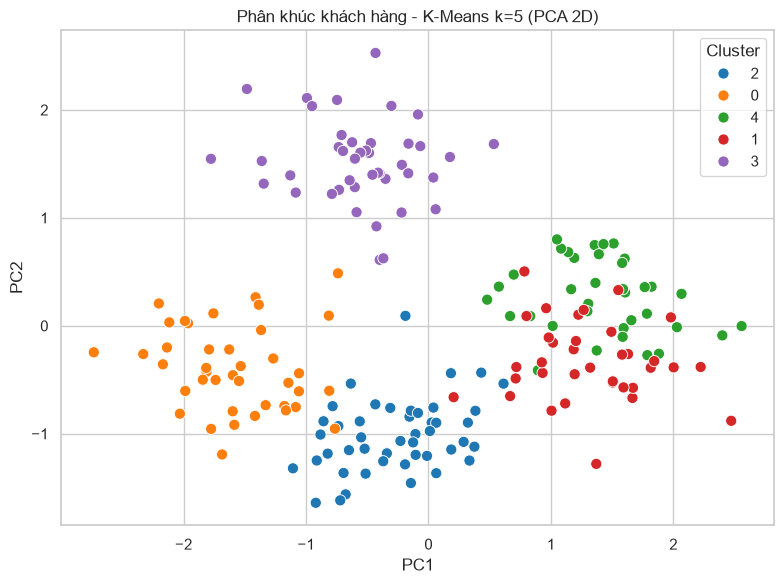

,Customers,Mean_Age,Mean_Income,Mean_Spending,Female_Rate
Cluster,,,,,
0,40,29.20,28.75,73.45,0.45
1,35,56.97,52.77,43.54,0.63
2,46,33.35,34.33,35.46,0.54
3,42,32.24,74.76,77.55,0.45
4,37,40.73,76.22,20.46,0.51


In [7]:
final_model = models[best_k]
df['Cluster'] = final_model.labels_
pca = PCA(n_components=2)
points_2d = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame(points_2d, columns=['PC1', 'PC2']).assign(Cluster=df.Cluster.astype(str))

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=65)
plt.title(f'Phân khúc khách hàng - K-Means k={best_k} (PCA 2D)')
plt.tight_layout()
plt.savefig(OUTPUT / '03_final_clusters_pca.png', dpi=160, bbox_inches='tight')
plt.show()

profile = df.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Mean_Age=('Age', 'mean'),
    Mean_Income=('Annual Income (k$)', 'mean'),
    Mean_Spending=('Spending Score (1-100)', 'mean'),
    Female_Rate=('Gender', lambda s: (s == 'Female').mean())
).round(2)
display(profile)
profile.to_csv(OUTPUT / 'cluster_profiles.csv')
df.to_csv(OUTPUT / 'customers_with_clusters.csv', index=False)

In [8]:
def segment_name(row):
    income = row['Mean_Income']; spend = row['Mean_Spending']; age = row['Mean_Age']
    if income >= 60 and spend >= 60: return 'Gia tri cao - uu tien cham soc'
    if income >= 60 and spend < 40: return 'Thu nhap cao - tiem nang kich hoat'
    if income < 45 and spend >= 60: return 'Chi tieu cao - nhay voi uu dai'
    if age >= 50: return 'Truong thanh - chi tieu on dinh'
    return 'Pho thong - can nuoi duong'

profile['Segment_Name'] = profile.apply(segment_name, axis=1)
display(profile)
profile.to_csv(OUTPUT / 'cluster_profiles_named.csv')

,Customers,Mean_Age,Mean_Income,Mean_Spending,Female_Rate,Segment_Name
Cluster,,,,,,
0,40,29.20,28.75,73.45,0.45,Chi tieu cao - nhay voi uu dai
1,35,56.97,52.77,43.54,0.63,Truong thanh - chi tieu on dinh
2,46,33.35,34.33,35.46,0.54,Pho thong - can nuoi duong
3,42,32.24,74.76,77.55,0.45,Gia tri cao - uu tien cham soc
4,37,40.73,76.22,20.46,0.51,Thu nhap cao - tiem nang kich hoat


## Step 7 - Classification mở rộng

Random Forest dự đoán **nhãn cụm K-Means** cho khách hàng mới. Đây là bài toán phân loại trên pseudo-label. Accuracy chỉ đo khả năng bắt chước K-Means, không chứng minh các phân khúc là nhãn đúng tuyệt đối trong thực tế.

Độ chính xác classification trên pseudo-label: 0.98
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        12
           3       1.00      0.90      0.95        10
           4       0.90      1.00      0.95         9

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



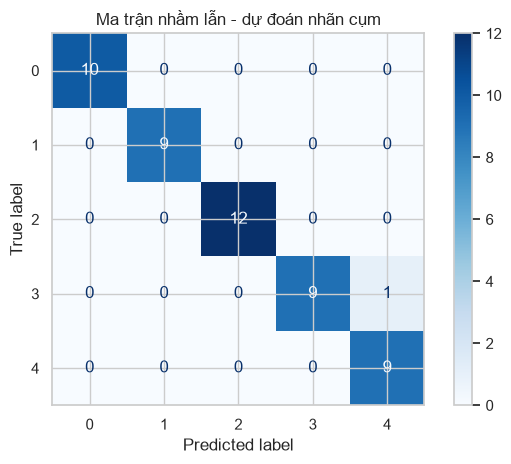

Ví dụ khách hàng mới được gán vào cụm: 3


In [9]:
feature_cols = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_cls = df[feature_cols]
y_cls = df['Cluster']
X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=.25, random_state=42, stratify=y_cls)

preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['Gender'])
])
classifier = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced'))
])
classifier.fit(X_train, y_train)
pred = classifier.predict(X_test)
print('Độ chính xác classification trên pseudo-label:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap='Blues')
plt.title('Ma trận nhầm lẫn - dự đoán nhãn cụm')
plt.tight_layout()
plt.savefig(OUTPUT / '04_classification_confusion_matrix.png', dpi=160, bbox_inches='tight')
plt.show()

report_text = classification_report(y_test, pred, zero_division=0)
(OUTPUT / 'classification_report.txt').write_text(
    f'Accuracy: {accuracy_score(y_test, pred):.4f}\n\n{report_text}', encoding='utf-8')

khach_hang_moi = pd.DataFrame([{
    'Gender': 'Female', 'Age': 30,
    'Annual Income (k$)': 70, 'Spending Score (1-100)': 80
}])
cum_du_doan = int(classifier.predict(khach_hang_moi)[0])
print('Ví dụ khách hàng mới được gán vào cụm:', cum_du_doan)


## Step 8 - Kết luận

- Đã hoàn thành EDA, kiểm tra missing/outlier, scaling, thử tham số, so sánh thuật toán và đánh giá nội bộ.
- Chọn K-Means theo Silhouette; kết quả chi tiết nằm trong `data/output/kmeans_metrics.csv`.
- Hồ sơ cụm hỗ trợ đề xuất chiến lược marketing; tên phân khúc là diễn giải nghiệp vụ, không phải nhãn có sẵn.
- Classification là phần mở rộng để gán nhanh khách hàng mới vào các segment đã học.
- Kết quả chỉ mang tính minh họa vì dữ liệu hiện tại là dữ liệu mô phỏng.